## Introduction

Twitter has become an important communication channel in times of emergency.
The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies).

But, it’s not always clear whether a person’s words are actually announcing a disaster.

In [1]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from wordcloud import WordCloud

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.offline as py
py.init_notebook_mode(connected=True)

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("../input/nlp-getting-started/train.csv")

## Statistical Analysis

In [3]:
# Print few rows of train data

train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


**Let's see the columns of data:**

* **id** - a unique identifier for each tweet
* **text** - the text of the tweet
* **location** - the location the tweet was sent from (may be blank)
* **keyword** - a particular keyword from the tweet (may be blank)
* **target** - in train.csv only, this denotes whether a tweet is about a real disaster (1) or not (0)

In [4]:
# Basic information

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
id          7613 non-null int64
keyword     7552 non-null object
location    5080 non-null object
text        7613 non-null object
target      7613 non-null int64
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [5]:
# Describing data

train.describe() 

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


In [6]:
# Data types of columns

train.dtypes

id           int64
keyword     object
location    object
text        object
target       int64
dtype: object

**Check missing/null values**

In [7]:
train.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

## Visualization

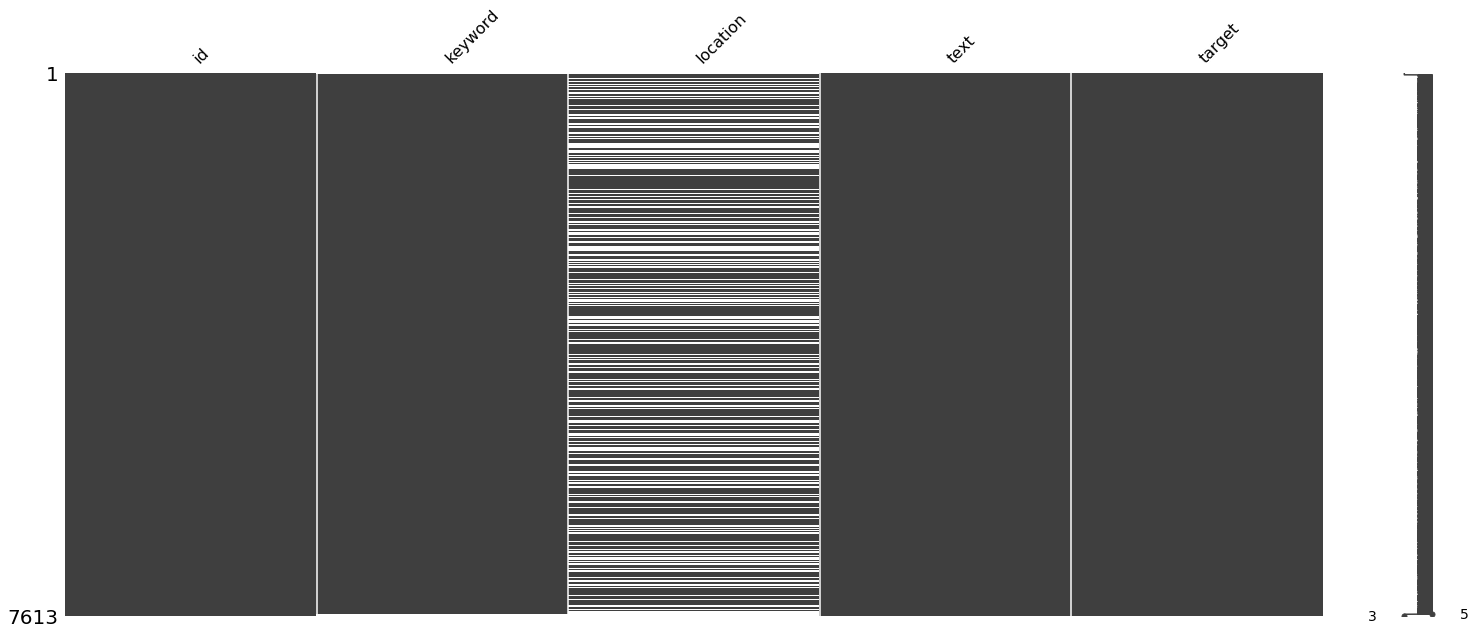

In [8]:
import missingno as msno
msno.matrix(train)

**Countrywise Distribution**

In [9]:
Loc = train['location'].value_counts()
fig = px.choropleth(Loc.values, locations=Loc.index,
                    locationmode='country names',
                    color=Loc.values,
                    color_continuous_scale=px.colors.sequential.OrRd)
fig.update_layout(title="Countrywise Distribution")
py.iplot(fig, filename='test')

**Categories of target column**

In [10]:
Tar = train['target'].value_counts()

fig = go.Figure([go.Bar(x=Tar.index, y=Tar)])
fig.update_layout(title = "Target Category")
py.iplot(fig, filename='test')

Seems like we have more number of tweets which are not disaster. Quite positive right!! 

**Most used words in text column**

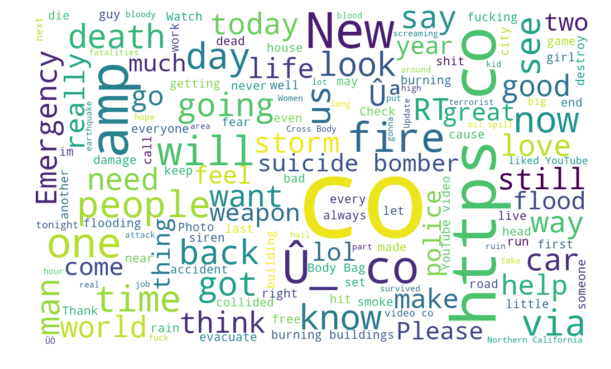

In [11]:
wordcloud = WordCloud(width = 1000, height = 600, max_font_size = 200, max_words = 150,
                      background_color='white').generate(" ".join(train.text))

plt.figure(figsize=[10,10])
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

**Most frequent keywords**

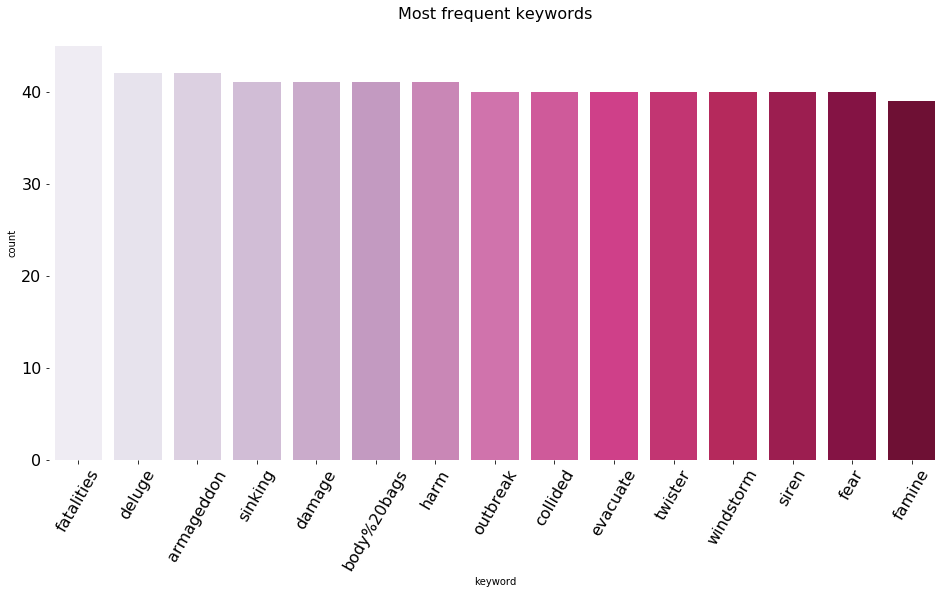

In [12]:
plt.figure(figsize=(16,8))
plt.title('Most frequent keywords',fontsize=16)
plt.xlabel('keywords')

sns.countplot(train.keyword,order=pd.value_counts(train.keyword).iloc[:15].index,palette=sns.color_palette("PuRd", 15))

plt.xticks(size=16,rotation=60)
plt.yticks(size=16)
sns.despine(bottom=True, left=True)
plt.show()

**If you like this kernel please upvote it or if you have any queries or suggestions then leave a comment.**

**I'll be adding more plots. Stay tuned!!**